<a href="https://colab.research.google.com/github/FishyFoshy/COMP3608-Project/blob/main/Dataset_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Cleaning of Dataset 3

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Load datasets
df3 = pd.read_csv('Dataset 3.csv')

# Drops all unnecessary columns
df3 = df3.drop(columns=['id', 'date', 'yr_renovated', 'zipcode', 'sqft_living15', 'sqft_lot15'])

# Drops all with null values
df3.dropna(inplace=True)

# Remove the top 1% highest prices to reduce high-end outliers before log-transform

df3_outr = df3.copy()
upper_quantile = df3_outr['price'].quantile(0.99)
df3_outr = df3_outr[df3_outr['price'] <= upper_quantile]


# Apply log transform to the target
df3['price'] = np.log(df3['price'])

# Create a copy of df3 for Linear Regression before feature engineering
df3lr = df3.copy()

# Apply location-based feature engineering to df3lr only (for Linear Regression)
df3lr['lat_lon_interaction'] = df3lr['lat'] * df3lr['long']
center_lat = df3lr['lat'].mean()
center_lon = df3lr['long'].mean()
df3lr['dist_to_center'] = np.sqrt((df3lr['lat'] - center_lat)**2 + (df3lr['long'] - center_lon)**2)
df3lr = df3lr.drop(columns=['lat', 'long'])  # Drop original lat/lon to avoid multicollinearity

# Separates non numerical columns from numerical ones
non_numerical_columns = ['price']

# Process df3lr (for Linear Regression): scale and encode
numerical_features_lr = [col for col in df3lr.columns if col not in non_numerical_columns]
scaler_lr = StandardScaler()
df3lr[numerical_features_lr] = scaler_lr.fit_transform(df3lr[numerical_features_lr])
categorical_cols_lr = df3lr.select_dtypes(include='object').columns
df3lr = pd.get_dummies(df3lr, columns=categorical_cols_lr, drop_first=True)

target_column = 'price'
x_lr = df3lr[[col for col in df3lr.columns if col != target_column]].copy()
y_lr = df3lr[target_column].copy()
x_train_lr, x_test_lr, y_train_lr, y_test_lr = train_test_split(x_lr, y_lr, test_size=0.2, random_state=42)

# Process df3 (for tree models: Random Forest, XGBoost): keep raw lat/lon, scale and encode
numerical_features = [col for col in df3.columns if col not in non_numerical_columns]
scaler = StandardScaler()
df3[numerical_features] = scaler.fit_transform(df3[numerical_features])
categorical_cols_to_encode = df3.select_dtypes(include='object').columns
df3 = pd.get_dummies(df3, columns=categorical_cols_to_encode, drop_first=True)

features = [col for col in df3.columns if col != target_column]
x = df3[features].copy()
y = df3[target_column].copy()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("=" * 60)
print("DATASET 3: Dataset 3.csv")
print("=" * 60)
print("\nFirst 10 rows:")
display(df3.head(10))
print("\nData types:")
print(df3.dtypes)
print("\nMissing values:")
print(df3.isnull().sum())
print("\nTarget variable (price) statistics:")
print(df3['price'].describe())

DATASET 3: Dataset 3.csv

First 10 rows:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,lat,long
0,12.309982,-0.398737,-1.447464,-0.979835,-0.228321,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.734708,-0.658681,-0.544898,-0.352572,-0.306079
1,13.195614,-0.398737,0.175607,0.533634,-0.189885,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.460841,0.245141,-0.681079,1.161568,-0.746341
2,12.100712,-1.473959,-1.447464,-1.426254,-0.123298,-0.915427,-0.087173,-0.305759,-0.629187,-1.409587,-1.229834,-0.658681,-1.293892,1.283537,-0.135655
3,13.311329,0.676485,1.149449,-0.130550,-0.244014,-0.915427,-0.087173,-0.305759,2.444294,-0.558836,-0.891699,1.397515,-0.204446,-0.283288,-1.271816
4,13.142166,-0.398737,-0.149007,-0.435422,-0.169653,-0.915427,-0.087173,-0.305759,-0.629187,0.291916,-0.130895,-0.658681,0.544548,0.409550,1.199335
5,14.018451,0.676485,3.097133,3.636791,2.096185,-0.915427,-0.087173,-0.305759,-0.629187,2.844170,2.537955,2.798440,1.021181,0.693181,1.483375
6,12.458775,-0.398737,0.175607,-0.397313,-0.200098,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,-0.088628,-0.658681,0.816910,-1.806810,-0.803149
7,12.583995,-0.398737,-0.798235,-1.110494,-0.130276,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.879623,-0.658681,-0.272536,-1.086547,-0.717937
8,12.343658,-0.398737,-1.447464,-0.326539,-0.184381,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.891699,0.990795,-0.374672,-0.344633,-0.874160
9,12.685408,-0.398737,0.500221,-0.206768,-0.206351,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.122706,-0.658681,1.089271,-1.383168,1.298749



Data types:
price            float64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition        float64
grade            float64
sqft_above       float64
sqft_basement    float64
yr_built         float64
lat              float64
long             float64
dtype: object

Missing values:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
lat              0
long             0
dtype: int64

Target variable (price) statistics:
count    21613.000000
mean        13.047817
std          0.526685
min         11.225243
25%         12.682152
50%         13.017003
75%         13.377006
max         15.856731
Name: price, dtype: float64


In [2]:
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import numpy as np
# Inverse the log transformation to its original scale

def rmse_original_scale(y_true, y_pred):
    y_true_original = np.exp(y_true)
    y_pred_original = np.exp(y_pred)
    # Calculate RMSE on the original scale
    return np.sqrt(mean_squared_error(y_true_original, y_pred_original))

def mae_original_scale(y_true, y_pred):
    y_true_original = np.exp(y_true)
    y_pred_original = np.exp(y_pred)
    # Calculate MAE on the original scale
    return mean_absolute_error(y_true_original, y_pred_original)

def r2_original_scale(y_true, y_pred):
    y_true_original = np.exp(y_true)
    y_pred_original = np.exp(y_pred)
    # Calculate R2 on the original scale
    return r2_score(y_true_original, y_pred_original)

# Create scorers that can be used with cross_val_score
neg_rmse_original_scorer = make_scorer(rmse_original_scale, greater_is_better=False)
neg_mae_original_scorer = make_scorer(mae_original_scale, greater_is_better=False)
r2_original_scorer = make_scorer(r2_original_scale, greater_is_better=True)

# Linear Regression for Dataset 3

In [5]:
from sklearn.model_selection import cross_val_score,cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,root_mean_squared_error,get_scorer_names, make_scorer
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn import metrics

model = LinearRegression()
model.fit(x_train,y_train)
predictions = model.predict(x_test)

----Log Space Metrics---
RMSE: $0.26
MAE: $0.20
r2: 0.7602

--- Real-Space Metrics ---
RMSE: $330,922.02
MAE: $120,547.23
r2: 0.2756

--- Cross Validated Scores ---
RMSE: $232,846.86
MAE: $114,168.65
r2: 0.5710



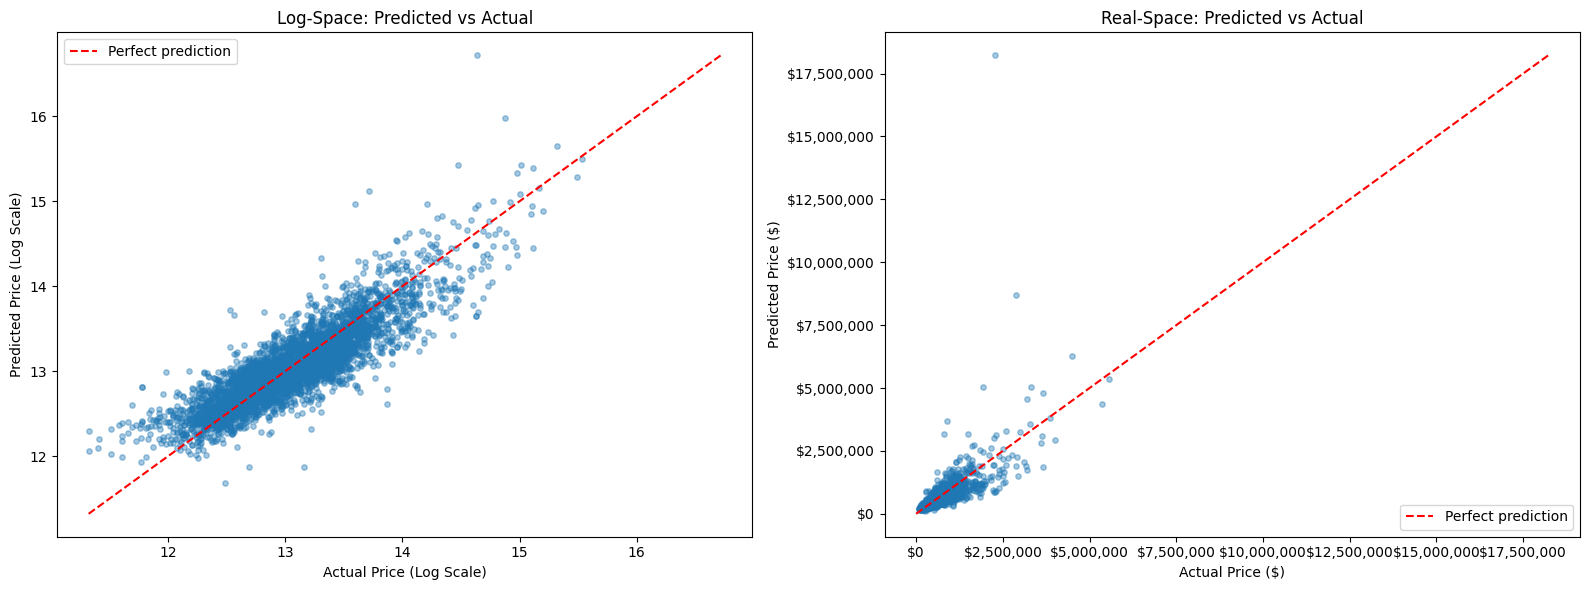

In [6]:
y_test_real = np.expm1(y_test)
predictions_real = np.expm1(predictions)

print("----Log Space Metrics---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test, predictions):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test, predictions):,.2f}")
print(f"r2: {metrics.r2_score(y_test, predictions):.4f}\n")

print("--- Real-Space Metrics ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_real, predictions_real):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test_real, predictions_real):,.2f}")
print(f"r2: {metrics.r2_score(y_test_real, predictions_real):.4f}\n")

from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse the log transformation to its original scale
def rmse_original_scale(y_true, y_pred):
    y_true_original = np.expm1(y_true)
    y_pred_original = np.expm1(y_pred)
    return np.sqrt(mean_squared_error(y_true_original, y_pred_original))

def mae_original_scale(y_true, y_pred):
    y_true_original = np.expm1(y_true)
    y_pred_original = np.expm1(y_pred)
    return mean_absolute_error(y_true_original, y_pred_original)

def r2_original_scale(y_true, y_pred):
    y_true_original = np.expm1(y_true)
    y_pred_original = np.expm1(y_pred)
    return r2_score(y_true_original, y_pred_original)

# Create scorers that can be used with cross_val_score
scoring_dict = {
    'rmse': make_scorer(rmse_original_scale, greater_is_better=False),
    'mae': make_scorer(mae_original_scale, greater_is_better=False),
    'r2': make_scorer(r2_original_scale, greater_is_better=True)
}

cv_results = cross_validate(model, x, y, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(y_test, predictions, alpha=0.4, s=15)
max_val_log = max(y_test.max(), predictions.max())
min_val_log = min(y_test.min(), predictions.min())
ax1.plot([min_val_log, max_val_log], [min_val_log, max_val_log], 'r--', label='Perfect prediction')
ax1.set_xlabel('Actual Price (Log Scale)') 
ax1.set_ylabel('Predicted Price (Log Scale)')
ax1.set_title('Log-Space: Predicted vs Actual')
ax1.legend()

ax2.scatter(y_test_real, predictions_real, alpha=0.4, s=15)
max_val_real = max(y_test_real.max(), predictions_real.max())
ax2.plot([0, max_val_real], [0, max_val_real], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual Price ($)') 
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Real-Space: Predicted vs Actual')
ax2.legend()

# Format the Real-Space graph to show dollar amounts
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

This dataset contains a small number of significant outliers. Even with a log transformation, these values remain too far from the majority of the data to allow for reliable predictions regarding high-end mansions. This small subset of extremely expensive properties violates the assumption of homoscedasticity (equal variance) required for linear regression.

Consequently, for this dataset, one can achieve a reasonably accurate model if the primary goal is to determine which 'price bucket' a house falls into; this explains the respectable R2 value of 0.76 in log space. However, as soon as granularity is reintroduced by converting the predictions back to their original scale, errors are magnified and accuracy plummets.

Given these constraints, it is logical to develop two separate models: one operating in log space(using log10)to identify extremely high-value properties, and another designed to differentiate between houses with price differences of less than $500,000.

Constructing the two linear models 

## Linear Model with the Outliers Removed

RMSE: $155,709.92
MAE: $108,249.02
r2: 0.6951

Cross-validation RMSE:	$155,253.18
Cross-validation MAE:	$108,052.35
Cross-validation R²:	0.7016


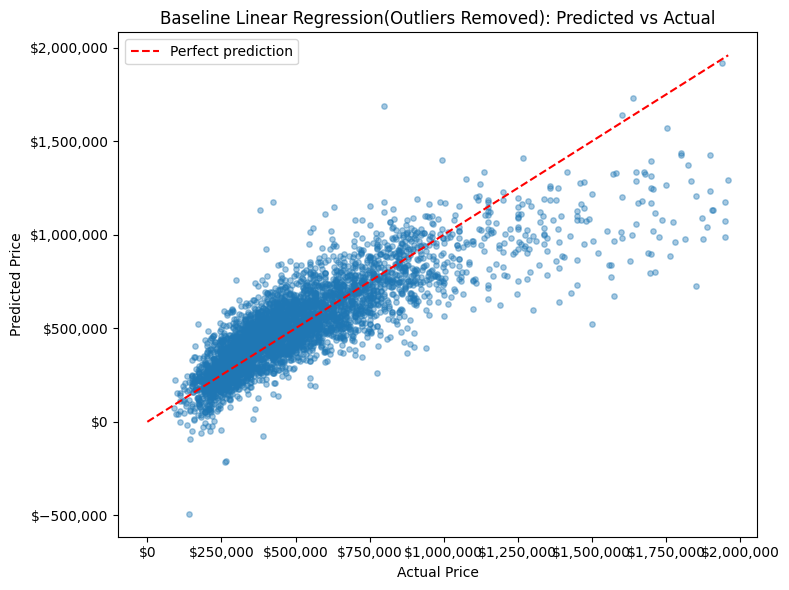

In [38]:
#Filter: Drop the extremely expensive houses
df3_outr = df3_outr[df3_outr['price'] < 2500000]


# Scale numerical features
scaler = StandardScaler()
df3_outr[numerical_features] = scaler.fit_transform(df3_outr[numerical_features])

# One-Hot Encodes all categorical data
categorical_cols_to_encode = df3_outr.select_dtypes(include='object').columns
df3_outr = pd.get_dummies(df3_outr, columns=categorical_cols_to_encode, drop_first=True)

#Extracting Features
target_column = 'price'
features = [col for col in df3_outr.columns if col != target_column]

#Creating "X" and "Y"
x_g = df3_outr[features].copy()
y_g = df3_outr[target_column].copy()

#Creating split
x_train_g, x_test_g, y_train_g, y_test_g = train_test_split(x_g, y_g, test_size=0.2, random_state=42)

#Creating Model
model_1 = LinearRegression()
model_1.fit(x_train_g, y_train_g)
predictions = model_1.predict(x_test_g)

#Printing Metrics
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_g, predictions):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test_g, predictions):,.2f}")
print(f"r2: {metrics.r2_score(y_test_g, predictions):.4f}")

#Cross Validated Metrics
print(f"\nCross-validation RMSE:\t${-cross_val_score(model_1, x_g, y_g, cv=5, scoring='neg_root_mean_squared_error').mean():,.2f}")
print(f"Cross-validation MAE:\t${-cross_val_score(model_1, x_g, y_g, cv=5, scoring='neg_mean_absolute_error').mean():,.2f}")
print(f"Cross-validation R²:\t{cross_val_score(model_1, x_g, y_g, cv=5, scoring='r2').mean():.4f}")

#Plotting Curve of Prediction vs Actual to show the accuracy 
plt.figure(figsize=(8, 6))
plt.scatter(y_test_g, predictions, alpha=0.4, s=15)
max_val = max(y_test_g.max(), predictions.max()) 
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price') 
plt.ylabel('Predicted Price')
plt.title('Baseline Linear Regression(Outliers Removed): Predicted vs Actual')
plt.legend()
ax = plt.gca() 
import matplotlib.ticker as ticker # Ensure ticker is imported
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.tight_layout()  
plt.show()

This model is more in line with what you'd expect from a well constructed linear model the measures of varaince and graphs are all within acceptable parameters. You could make the model even more accurate by getting rid of the cluster past 2 million this would yield a model closer to 75% however culling good data is generally bad practice in Machine Learning/Data Science.

### Further Analyisis of the Model with the Outliers Removed

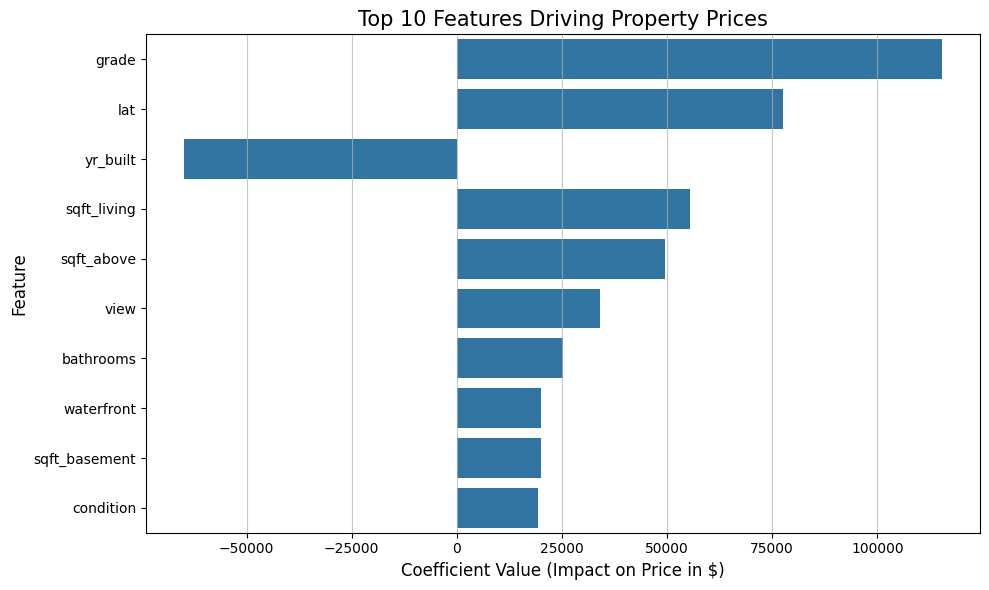

,Feature,Coefficient
8,grade,115418.343859
12,lat,77690.411529
11,yr_built,-64935.203954
2,sqft_living,55524.980632
9,sqft_above,49565.185761
6,view,33981.658257
1,bathrooms,25326.839950
5,waterfront,19969.557695
10,sqft_basement,19967.802430
7,condition,19341.804907


In [39]:
import seaborn as sns
#Fetching Feature Names and Coefficents
feature_names = x_train_g.columns
coefficients = model_1.coef_

#Wrapping them together in a Pandas DataFrame for Easy Comparision and Viewing
feature_importance = pd.DataFrame({
 'Feature': feature_names,
 'Coefficient': coefficients
})

#Using the Absolute Function in the NumPy Library before Sorting the Coefficents in Decending Order
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
top_10_features = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
sns.barplot(
 data=top_10_features, 
 x='Coefficient', 
 y='Feature', 
)

#Graph of the Top 10 features
plt.title('Top 10 Features Driving Property Prices', fontsize=15)
plt.xlabel('Coefficient Value (Impact on Price in $)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()
display(top_10_features[['Feature', 'Coefficient']])

According to the graph, the one negative predictor at the top 10 features is yr_built. The later the houses are constructed, the lower the estimated price of the houses when all other characteristics remain constant. This could be because more recent developments are often sold by institutional investors who are incentivised to sell inventory at a high price within a short period of time at or below market prices, whereas older homes are normally sold through conventional methods at full market value.

The strongest positive predictor is grade (build quality) by a significant margin, the correlation coefficient of which is approximately 1.5x higher than the next feature, which is lat (latitude). The dominance of latitude indicates the geographic premiums that are assigned to the properties in more northerly (higher-latitude) neighbourhoods within this dataset.

The rest of the positive predictors, which include: sqft_living, sqft_above, view, bathrooms, waterfront, sqft_basement and condition follow more traditional expectations in that larger, better-positioned, and feature-rich properties command higher prices. It is worth noting that the quality of a building ( `grade` ) has an enormous influence on the estimated price.

## Log Scaled Model Features Evaulation

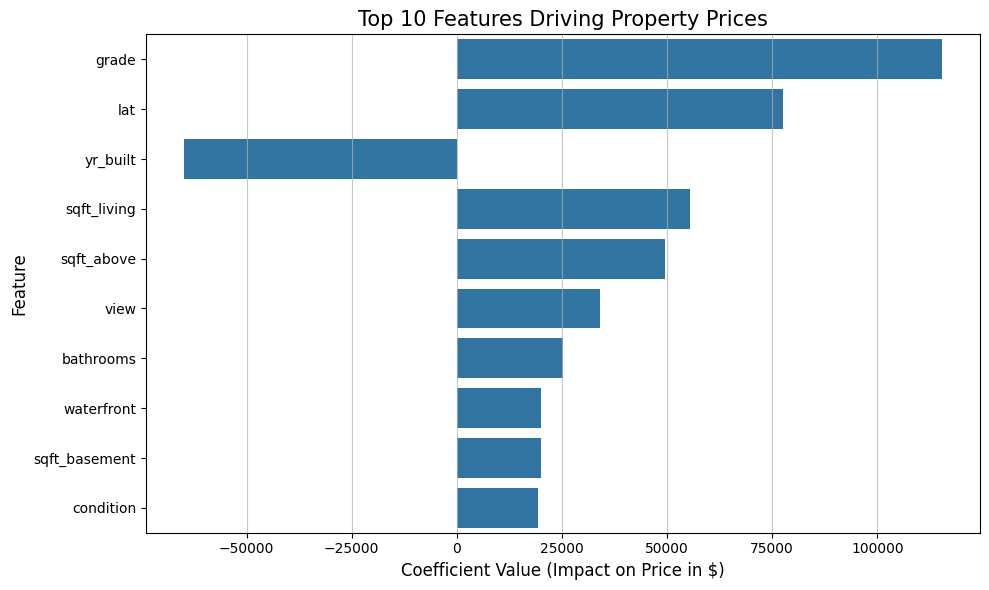

,Feature,Coefficient
8,grade,115418.343859
12,lat,77690.411529
11,yr_built,-64935.203954
2,sqft_living,55524.980632
9,sqft_above,49565.185761
6,view,33981.658257
1,bathrooms,25326.839950
5,waterfront,19969.557695
10,sqft_basement,19967.802430
7,condition,19341.804907


In [40]:
#Fetching Feature Names and Coefficents
feature_names = x_train.columns
coefficients = model_1.coef_

#Wrapping them together in a Pandas DataFrame for Easy Comparision and Viewing
feature_importance = pd.DataFrame({
 'Feature': feature_names,
 'Coefficient': coefficients
})

#Using the Absolute Function in the NumPy Library before Sorting the Coefficents in Decending Order
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
top_10_features = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
sns.barplot(
 data=top_10_features, 
 x='Coefficient', 
 y='Feature', 
)
#Graph of the Top 10 features
plt.title('Top 10 Features Driving Property Prices', fontsize=15)
plt.xlabel('Coefficient Value (Impact on Price in $)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()
display(top_10_features[['Feature', 'Coefficient']])


The target variable (price) was only subjected to the log transform, as opposed to the feature X. Since the predictors themselves are the same, the ranking and direction of each coefficient are the same as in the previous model, with grade staying the strongest positive predictor, lat second and yr built the only negative predictor.

The values of the coefficients here are in log-dollar values and not in raw dollars and therefore cannot be directly compared to the values in the previous model. Nevertheless, the relative ranking and the logic discussed in the outliers-eliminated analysis holds: the quality of the building and the location drive the price upwards, whereas the more recent the building is constructed, the lower the predicted value.

## Random Forest Regression

In [41]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest... This may take a moment depending on dataset size.")
rf_model.fit(x_train, y_train)

# Generate predictions on the log-scaled test set
rf_predictions = rf_model.predict(x_test)

#Generate Cross Validation Metrics in Log Space
print("\n--- Log-Space Metrics (Random Forest) ---")
print(f"RMSE: {metrics.root_mean_squared_error(y_test, rf_predictions):.4f}")
print(f"MAE:  {metrics.mean_absolute_error(y_test, rf_predictions):.4f}")
print(f"R²:   {metrics.r2_score(y_test, rf_predictions):.4f}\n")

print(f"\nCross-validation RMSE:\t{-cross_val_score(rf_model, x, y, cv=5, scoring='neg_root_mean_squared_error').mean():,.2f}")
print(f"Cross-validation MAE:\t{-cross_val_score(rf_model, x, y, cv=5, scoring='neg_mean_absolute_error').mean():,.2f}")
print(f"Cross-validation R²:\t{cross_val_score(rf_model, x, y, cv=5, scoring='r2').mean():.4f}")

#Real Space Metrics
y_test_real = np.expm1(y_test)
rf_predictions_real = np.expm1(rf_predictions)

print("--- Real-Space (Dollar) $ Metrics (Random Forest) ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_real, rf_predictions_real):,.2f}")
print(f"MAE:  ${metrics.mean_absolute_error(y_test_real, rf_predictions_real):,.2f}")
print(f"R²:   {metrics.r2_score(y_test_real, rf_predictions_real):.4f}\n")

# Cross Validation for the RF model
cv_results = cross_validate(rf_model, x, y, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")

Training Random Forest... This may take a moment depending on dataset size.

--- Log-Space Metrics (Random Forest) ---
RMSE: 0.1778
MAE:  0.1269
R²:   0.8890


Cross-validation RMSE:	0.18
Cross-validation MAE:	0.13
Cross-validation R²:	0.8871
--- Real-Space (Dollar) $ Metrics (Random Forest) ---
RMSE: $137,538.41
MAE:  $72,356.22
R²:   0.8749

--- Cross Validated Scores ---
RMSE: $135,434.99
MAE: $70,664.43
r2: 0.8633



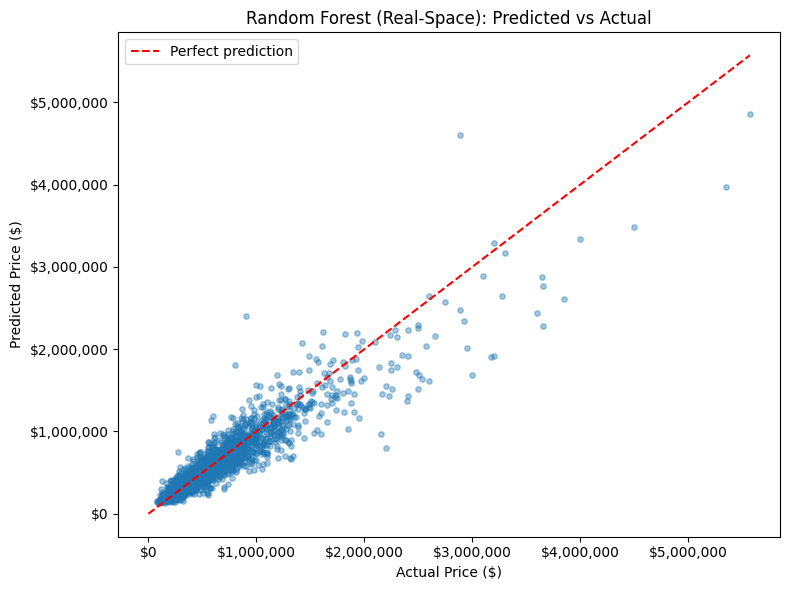

In [42]:
#Real-Space Graph
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(y_test_real, rf_predictions_real, alpha=0.4, s=15)
max_val_real = max(y_test_real.max(), rf_predictions_real.max())
ax2.plot([0, max_val_real], [0, max_val_real], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual Price ($)') 
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Random Forest (Real-Space): Predicted vs Actual')
ax2.legend()
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

Since the Random Forest is a non-parametric group approach, it does not make the assumption, that the variance of errors is constant across all independent variables, that limits linear regression to this data. Since it was trained on the full log-scaled set, which would be the same as that used to train the original linear regression model, it can easily accommodate high-end outliers without the need to remove them.

When compared to the original full-dataset linear model on the same test split, the improvements are significant: RMSE drops by about 58%, MAE by about 40%, and the value of R² increases from its value of 0.28 to 0.87 in real space. The comparison to the outliers-removed linear model is less clear, in that the two models are run on different subsets of the data; however, MAE still improves by about 35% and R² by about 24% but with an RMSE decrease of about 13%.

Overall, the Random Forest can achieve better predictive performance on all key metrics as a whole, not being subjected to outlier-filtering or training on a reduced dataset.

### Analyisis of Feature Importance for The Random Forest Model

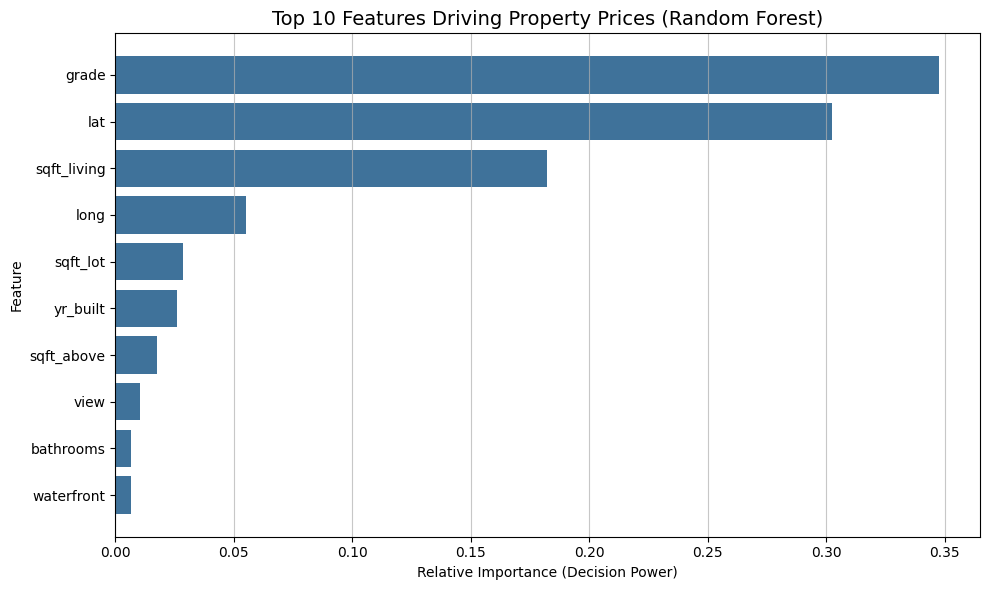

In [43]:

#Extract the feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = x_train.columns
feature_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

#Sorting By importance
top_10_features = feature_df.sort_values(by='Importance', ascending=True).tail(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='#3f729a') 
plt.xlabel('Relative Importance (Decision Power)')
plt.ylabel('Feature')
plt.title('Top 10 Features Driving Property Prices (Random Forest)', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.7) 
plt.tight_layout()
plt.show()

The most notable feature of the Random Forest importance rankings is that the top two features, namely, grade and lat, together, contribute to about 65% of the total decision power of the model, with grade and lat respectively taking about 35% and 30% of this power.

The most notable shift with the linear model is that a new feature, long (longitude), emerges as the fourth most important feature. The longitude was not among the top 10 of the linear model at all, indicating that the Random Forest does not adopt the linear spatial interactions that the linear model fails to capture. The linear model assumed that latitude is the only geographic signal that is meaningful, as opposed to the Random Forest, which assumes that both spatial coordinates are meaningful, although it still places a lot more emphasis on latitude.

sqft_lot also enters the top 10 here, replacing both sqft_basement and condition, which were present in the top 10 of the linear model but do not appear here. This suggests that the Random Forest is more focused on the total land area than on interior sub-features when the full set of data including high-value outliers has been included.

## Tweaked Random Forest 

In [44]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from scipy.stats import randint, uniform

rf_model = RandomForestRegressor(random_state=42)

param_distributions = {
    'n_estimators': randint(10, 500),      
    'max_depth': randint(1, 50), 
    'max_features': uniform(0, 1),         
    'min_samples_leaf': randint(1,10),
        
}

rf_random = RandomizedSearchCV(
    estimator=rf_model, 
    param_distributions=param_distributions, 
    n_iter=200,                           
    cv=5,      
    scoring= scoring_dict,  
    refit= 'mae',             
    random_state=42,
    n_jobs= -1
)

rf_random.fit(x_train, y_train)
print("Best Parameters:", rf_random.best_params_)

rf_predictions = rf_random.predict(x_test)
y_test_rs = np.expm1(y_test)
rf_predictions_rs = np.expm1(rf_predictions)

Best Parameters: {'max_depth': 36, 'max_features': np.float64(0.8062012797930613), 'min_samples_leaf': 1, 'n_estimators': 364}


In [45]:
#Printing Values
print("--- Real-Space (Dollar) $ Metrics (Random Forest) ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_rs, rf_predictions_rs):,.2f}")
print(f"MAE:  ${metrics.mean_absolute_error(y_test_rs, rf_predictions_rs):,.2f}")
print(f"R²:   {metrics.r2_score(y_test_rs, rf_predictions_rs):.4f}\n")

cv_results = cross_validate(rf_random.best_estimator_, x, y, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")

--- Real-Space (Dollar) $ Metrics (Random Forest) ---
RMSE: $137,092.90
MAE:  $72,153.18
R²:   0.8757

--- Cross Validated Scores ---
RMSE: $134,094.73
MAE: $69,931.61
r2: 0.8660



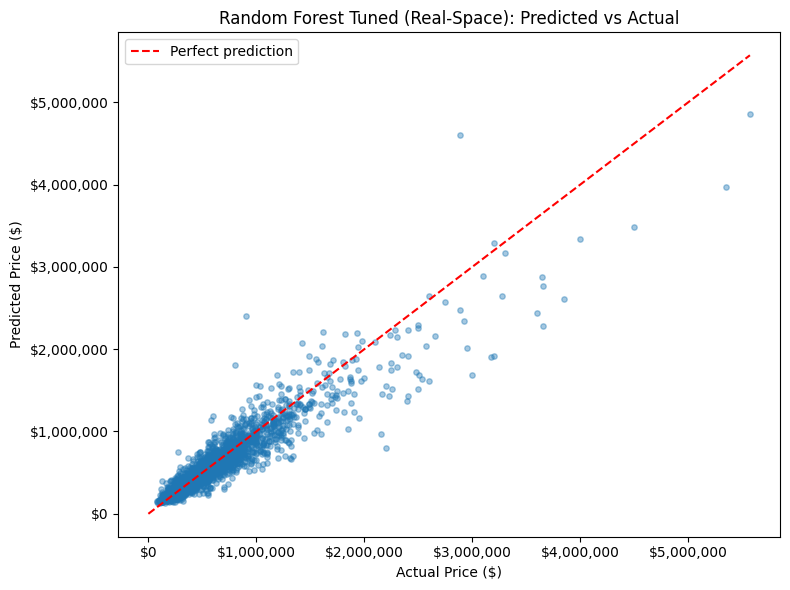

In [46]:
#Graph for tuned RF
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(y_test_real, rf_predictions_real, alpha=0.4, s=15)
max_val_real = max(y_test_real.max(), rf_predictions_real.max())
ax2.plot([0, max_val_real], [0, max_val_real], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual Price ($)') 
ax2.set_ylabel('Predicted Price ($)')
ax2.set_title('Random Forest Tuned (Real-Space): Predicted vs Actual')
ax2.legend()
formatter = ticker.StrMethodFormatter('${x:,.0f}') 
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

The model had slight improvements in all measures after hyperparameter tuning using the RandomizedSearchCV. RMSE fell by roughly $445 (~0.3%), MAE by ~$203 (~0.3%), and R² increased by less than 0.001. Cross-validated scores are no different, being smaller but steady increases.

The performance increase between the base Random Forest settings and 200 search iterations and 5-fold cross-validation is minimal, implying that the base parameter configuration of the Random Forest was already close to optimal in this case. The bottleneck is not the model's hyperparameters but the data itself. The high value outliers that remain in the full dataset, introduce an irreducible variance that cannot be removed by any amount of tuning. Obtaining a larger, more representative sample of high-end properties would probably yield a more significant improvement than additional hyperparameter optimization

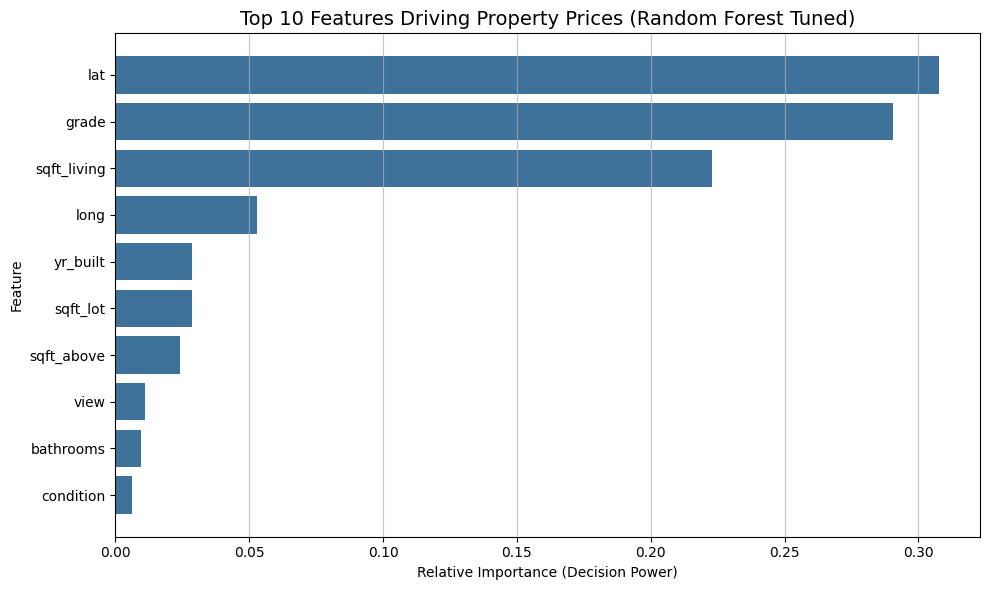

In [47]:
#Extract the feature importances from the Random Forest model
rf_model = rf_random.best_estimator_
importances = rf_model.feature_importances_
feature_names = x_train.columns
feature_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

#Sorting By importance
top_10_features = feature_df.sort_values(by='Importance', ascending=True).tail(10)

#Plotting Graph
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='#3f729a') 
plt.xlabel('Relative Importance (Decision Power)')
plt.ylabel('Feature')
plt.title('Top 10 Features Driving Property Prices (Random Forest Tuned)', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.7) 
plt.tight_layout()
plt.show()

The feature ranking at the top by the tuned model shifted from grade (now ~29%) to lat (now ~31) as the most important predictor, whereas in the base Random Forest the most important predictor was grade (at ~35%) followed by lat (at ~30%). The difference is small, about 2%, so the two features are almost equally dominant, yet the order did flip.

A more significant change is that the feature of sqft_living has risen to the 3rd place at approximately 22%, making the top three features together account for over 80% of the model's total decision. In the base model the importance was more concentrated with just the top two features. The weight of geographic and physical size features is slightly more evenly distributed across the tuned model, which aligns with the hyperparameter search favouring configurations that capture a broader set of interactions. (i.e. a large number of n_estimators and a large max_depth)

#xgboost


In [7]:
from xgboost import XGBRegressor

model =XGBRegressor(random_state=42)
model.fit(x_train,y_train)

xpred_test =model.predict(x_test)

cv_results = cross_validate(model, x_train, y_train, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")

y_test_real = np.expm1(y_test)
xpred_test = np.expm1(xpred_test)

print("--- Real-Space Metrics ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_real, xpred_test):,.2f}")
print(f"MAE: ${metrics.mean_absolute_error(y_test_real, xpred_test):,.2f}")
print(f"r2: {metrics.r2_score(y_test_real, xpred_test):.4f}\n")

--- Cross Validated Scores ---
RMSE: $120,798.73
MAE: $67,330.83
r2: 0.8879

--- Real-Space Metrics ---
RMSE: $130,088.40
MAE: $70,230.58
r2: 0.8881



From the results of the xgboost mode, we see in the cross validation, the model had an mae 67,330.83 ,a rmse of 120,798.73 and a r2 of .88. this mean the model's predictions were on avg off by 67,330.83 from the actual price and explained 88% of the training dataset's variance.

from the testing results, the model had an mae 70,230.58 ,a rmse of 130,088.40and a r2 of .88. this mean the model's predictions were on avg off by 70,230.58 from the actual price and explained 88% of the training dataset's variance.

from both results, we observed that the model perfromanec dropped slightly in the test dataset, this is expected, meaning that the model has a good fit with no immmedate evidence of overfitting and underfitting.

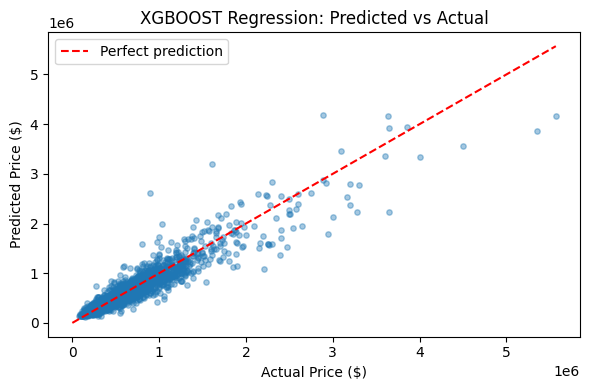

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(y_test_real, xpred_test, alpha=0.4, s=15)
max_val = max(y_test_real.max(), xpred_test.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('XGBOOST Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

from the graph of xgboost regression :predicted vs actual, it was observed the model preformed differently according to the price, with 3 noticeable categories. In houses priced under 1.5 million, the model preformace well with the x=y line in the middle of the plots. the predictions being centered around the prediction line implies that low - moderate bias and the predictions being dense or close together means there was also low variance. this proves the model was able to gain a general understanding of the lower priced houses. however in the price range of 1.5 million to 2.5 million, it was observed that perfromace begain to degrade, with predictions starting to diverge from the prediction line. this means that prediction are becoming slightly sparce, leading to an moderate increase in variance. there was also an increase in the number of underpredictions compared to acturate and overprediction, meaning a increase in bias. in the price range, there was a decrease in preformace but the model still preformed well, with mostly underpredicted prices. in the 2.5 million and higher price range, we observed predictions increased in sparcity and distance from the prediction line, this means high variance and high - moderate bias, due the model being able to make some accurate predictions.

overall, the trend of as price increase, model preformance begain to decrease, meaning the model was able to generalised the lower price range but begain to struggle with making the relationships with features to price in the middle to higher price ranges. this model is best suited for prediction in the lower and middle price range but should not be used for houses price higher than 2.5 million.

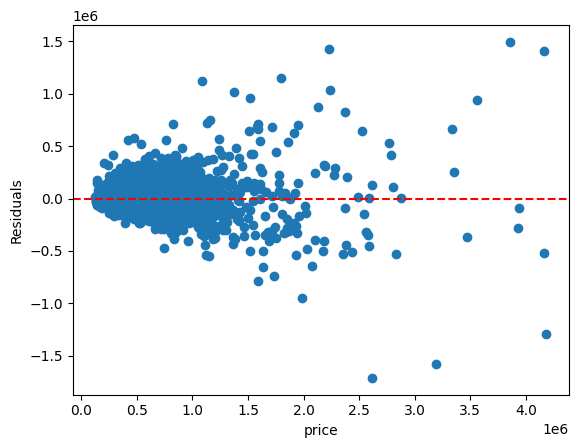

In [9]:
res = y_test_real - xpred_test

plt.scatter(xpred_test, res)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('price')
plt.ylabel('Residuals')
plt.show()

from the residual plot for the xgboost, it was observed a symmetric plot, with predictions under 2 were clustered around but as price increase, plots begin to diverge, giving a funnel shaped which is common as tree regressor dont assume equal variance. this meant the model was struggling at higher price ranges, comfirming observations in the XGBOOST Regression: Predicted vs Actual graph, this is due to unequal variance in the residuals so as price increase, the predictions errors increase as well, which can cause the high RMSE seen which was almost double the MAE. the r2 of 88% is also confirmed with majority of the dataset being composed of low and middle prices house also seen in XGBOOST Regression: Predicted vs Actual graph where high priced home were lesser in numbers. overall the model is confirmed to has a good fit with equal underprediction and overpredictions.

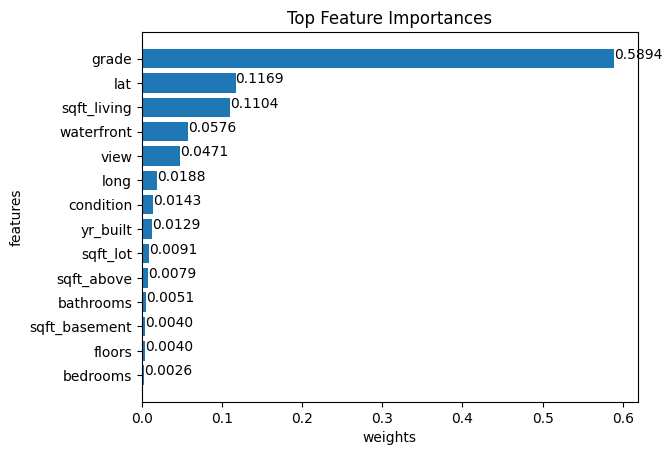

In [10]:
importances =model.feature_importances_
feature_df =pd.Series(importances,index=x_train.columns)
feature_df=feature_df.sort_values(ascending=True).reset_index()
feature_df.columns =["Feature","Weight"]

plt.barh(feature_df['Feature'], feature_df['Weight'])
plt.title('Top Feature Importances')
plt.xlabel('weights')
plt.ylabel("features")
for u,i in enumerate(feature_df["Weight"]):
  plt.text(i,u,f"{i:.4f}")
plt.show()

from the grpah of Top Feature Importances, we see the highest feature is grade of 0.59. this rasies a slight concern of the model being over dependent on the grade feature alone, as the next feature lat has a value 0.12. this is followed by sqft_living of 0.11 , waterfront of 0.058 and view of 0.047. these 5 features added up to 0.92 which is higher than expected but being high importance is expected as higher grade means higher price and the same pattern for living space, waterfront and view. however, for lat(0.11) and long(0.018), lat having a higher value eludes to some relationship that with the location but more anlysis is needed to determined its nature. the remaining featuers such as bedrooms, bathrooms, floors etc provided minimal importance which contridicted inital assumptions in the housing market with these features providing higher importance.from the graph we see that bathrooms had a higher feature importance than bedrooms, while both in housing market are of high importance, the model has learned that they had little impact on price.

XGBOOST Hyperparamater tuning

In [11]:
import sklearn 
hp_model=XGBRegressor(random_state=42)
params = {
    'n_estimators': [100, 300, 600,650,625, 800],
    'max_depth': [3, 6, 4,7,5,2],
    'learning_rate': [0.01,0.08,0.3 ,0.03, 0.05,0.1],
    'reg_lambda': [2,2.5,5,10,12,7]
}

xg_random=sklearn.model_selection.RandomizedSearchCV(estimator=hp_model,
            param_distributions=params,
            cv=5,
            n_iter=100,
            scoring= scoring_dict,  
            refit= 'mae',             
            n_jobs =-1,
            verbose=5,
            return_train_score=True,
            random_state=42)

xg_random.fit(x_train, y_train)
print("Best Parameters:", xg_random.best_params_)

best_model= xg_random.best_estimator_
xg_predictions = best_model.predict(x_test)
y_test_org = np.expm1(y_test)
xg_predictions_org = np.expm1(xg_predictions)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5] END learning_rate=0.3, max_depth=5, n_estimators=650, reg_lambda=12; mae: (train=-26162.155, test=-66684.063) r2: (train=0.987, test=0.899) rmse: (train=-40706.409, test=-124816.799) total time=   1.9s
[CV 2/5] END learning_rate=0.3, max_depth=5, n_estimators=650, reg_lambda=12; mae: (train=-26511.216, test=-68616.913) r2: (train=0.987, test=0.881) rmse: (train=-41382.306, test=-126591.114) total time=   2.0s
[CV 4/5] END learning_rate=0.3, max_depth=5, n_estimators=650, reg_lambda=12; mae: (train=-26811.112, test=-65609.022) r2: (train=0.987, test=0.897) rmse: (train=-41777.987, test=-112752.839) total time=   2.1s
[CV 3/5] END learning_rate=0.3, max_depth=5, n_estimators=650, reg_lambda=12; mae: (train=-26037.051, test=-66821.335) r2: (train=0.988, test=0.899) rmse: (train=-40246.431, test=-114668.811) total time=   2.2s
[CV 5/5] END learning_rate=0.3, max_depth=5, n_estimators=650, reg_lambda=12; mae: (train=-26

After tuning, the best parameters were reg lamda = 5( this makes the model more conservative, helping to reduce overfitting), numder of estimators = 600, max depth of each tree was 7 and learning rate was 0.05.

In [12]:
print("--- testing Scores ---")
print(f"RMSE: ${metrics.root_mean_squared_error(y_test_org, xg_predictions_org):,.2f}")
print(f"MAE:  ${metrics.mean_absolute_error(y_test_org, xg_predictions_org):,.2f}")
print(f"R²:   {metrics.r2_score(y_test_org, xg_predictions_org):.4f}\n")

cv_results = cross_validate(best_model, x, y, cv=5, scoring=scoring_dict, return_train_score=True)

print("--- Cross Validated Scores ---")
print(f"RMSE: ${-cv_results['test_rmse'].mean():,.2f}")
print(f"MAE: ${-cv_results['test_mae'].mean():,.2f}")
print(f"r2: {cv_results['test_r2'].mean():.4f}\n")

--- testing Scores ---
RMSE: $124,191.81
MAE:  $66,312.04
R²:   0.8980

--- Cross Validated Scores ---
RMSE: $122,265.48
MAE: $65,027.31
r2: 0.8888



From the results of the tuned xgboost model, we see in the cross validation, the model had an mae 65,027.31 ,a rmse of 122,265.48 and a r2 of .88. this mean the model's predictions were on avg off by 65,027.31 from the actual price and explained 88% of the training dataset's variance.

from the testing results, the model had an mae 66,312.04 ,a rmse of 124,191.81.40 and a r2 of .89. this mean the model's predictions were on avg off by 66,312.04.58 from the actual price and explained 88 of the training dataset's variance. from these results, no overfitting or underfitting was observed due the decrease in preformace with the testing, as expected

in comparison with the untuned xgboost model, the cross validation result, a decrease in MAE from 67,330.83 to 65,027.31, meaning that on average the tuned model predictions were closer to the actual price. however, there was a increase in the rmse from 120,798.73 to 122,265.48 in the tuned model, this usually indicates the increase in the presents of large errors either that there was slight overfitting in the untuned model or result of misunderstood relationships. there was also no increase in explained variance with both models having 88%.

in the testing dataset, it was observed an improvement in every metric, in the MAE from 70,230.58 to 65,027.31, the RMSE in the untuned model from 130,088.40 to 124,191.81.40 and r2 from 88% to 89%. the inconsistency the tuned cross validation rmse result being higher than the untuned dataset but still higher than the tuned testing can be attributed to records in the cross validation set that the model is struggling with predictions which are absent but not a confirmed reason.

overall, it was a observed there was a slight improvement due to the tuning process, however, this hyperparameter tuning was performed with the goal of reducing overfitting (if any) and not better performance. maybe, if a different combination of parameters are used even better preformance increase can be achieved(this is an assumption and can be wrong)

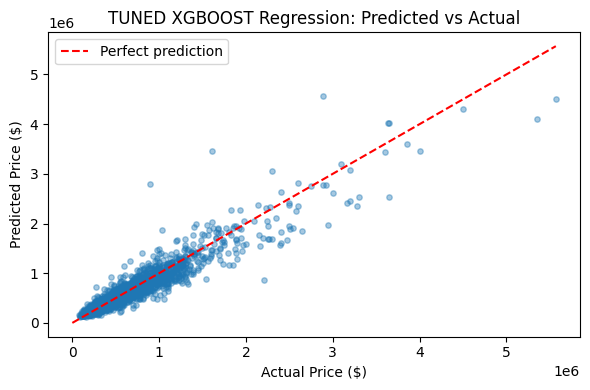

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(y_test_org, xg_predictions_org, alpha=0.4, s=15)
max_val = max(y_test_org.max(), xg_predictions_org.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('TUNED XGBOOST Regression: Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

from the TUNED XGBOOST Regression: Predicted vs Actual, the overall shape is similar to the untuned prediction graph. this is due to the slight increase in performace, a few plots are closer to the prediction line causing a reduction in variance and bias (due to the lower rmse) but the general tend of the untuned model still holds true for the tuned model, as price increase, performance decreases. there are also plots that are worse after tuning, most noticeable are 3 overprediction for houses prices at 1 million, 1.8 million and 3 million respectively. these overpredictions prediction increased when compared to the untuned model. this shows the tuned model didnot improve in every prediction but there are some relationship that were adjusted in a negative manner.

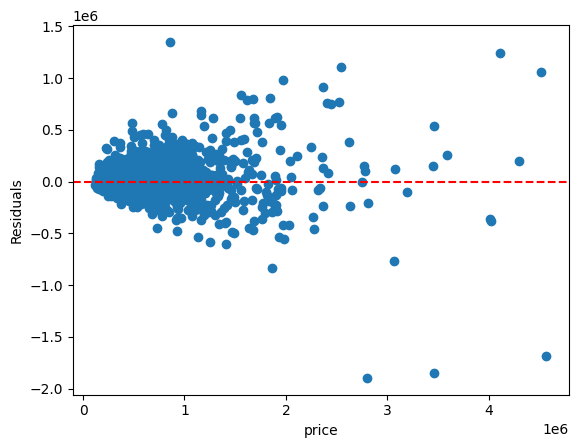

In [14]:
xg_res = y_test_org - xg_predictions_org

plt.scatter(xg_predictions_org, xg_res)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('price')
plt.ylabel('Residuals')
plt.show()

from the residual plot above, a symmetrically plot is observed, however, a reduction in the number of overpredictions with plots becoming more clustered around y=0 line and less sparce. this confirms that variance and bias is reducted.however, there are increase in the some overprediction as seen by the house price 2.8 million, 3.5 million and 4.8 million which increase from around 1.5 million to approximately 2 million but due there consistently being overpredicted they make be classifed as outliers. the funnel shape is less distinct but is still present, mostly present on the underpredictions and slight present on the overprediction side(mostly due to the 3 plot previously mentioned). the model has shown improvement in the 2 million price range with a reduction in the number of overpredictions. overall the model still appears to struggle in the higher price range with underpredictions but moderate improvement as seen by higher price range beoming less symetrically and more random plots, implying a more general fit in the upper price range and the middle price range.

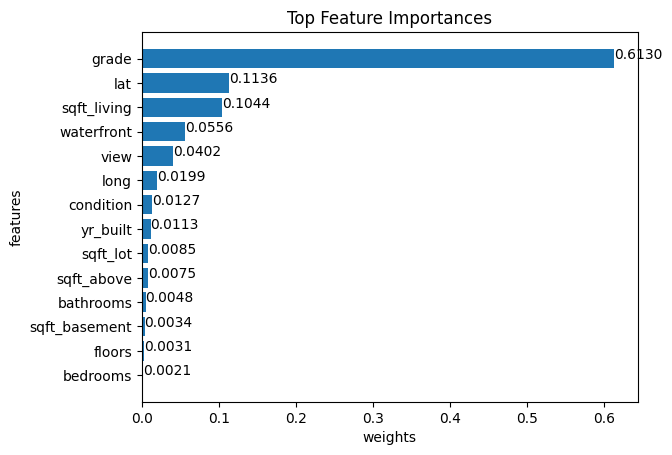

In [15]:
importances =best_model.feature_importances_
feature_df =pd.Series(importances,index=x_train.columns)
feature_df=feature_df.sort_values(ascending=True).reset_index()
feature_df.columns =["Feature","Weight"]

plt.barh(feature_df['Feature'], feature_df['Weight'])
plt.title('Top Feature Importances')
plt.xlabel('weights')
plt.ylabel("features")
for u,i in enumerate(feature_df["Weight"]):
  plt.text(i,u,f"{i:.4f}")
plt.show()

from the feature importance of tuned model, there was a observed decrease in a all features expect grade and long which had slight increases without change in feature position. the tuned model has become over dependent on the grade feature, with the value from 0.59 to 0.61 and long from 0.0188 to 0.0199. overall the model has remained consistent throughout tuning without signs of over fitting and under fitting, with grade being the main predictor towards the price and showed improvement in testing.